In [82]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/iammustafatz/diabetes-prediction-dataset/diabetes_prediction_dataset.csv


# Diabetes Data Classification

This notebook applies classification techniques to predict diabetes status based on patients’ medical and demographic data.

The model learns patterns from features such as age, BMI, HbA1c level, blood glucose level, hypertension, heart disease, smoking history, and gender.

### Goal:
To classify each patient as:

- **0 = Non-Diabetic**
- **1 = Diabetic**

In [83]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [84]:
df = pd.read_csv('/kaggle/input/datasets/iammustafatz/diabetes-prediction-dataset/diabetes_prediction_dataset.csv')
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [85]:
df.shape

(100000, 9)

<Axes: xlabel='diabetes', ylabel='count'>

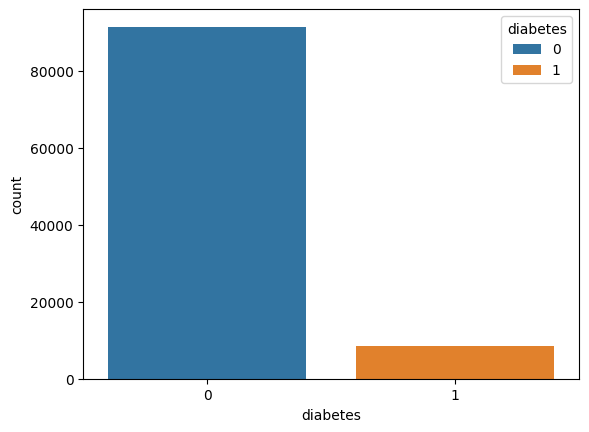

In [86]:
import seaborn as sns 

sns.countplot(data=df, x="diabetes", hue="diabetes")

In [87]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


### Dataset Overview

The dataset contains 100,000 patient records with 9 features.
There are no missing values, making it suitable for machine learning classification tasks.

In [89]:
df.isnull().sum()
# There is no Missing value

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [90]:
df.duplicated().sum()

np.int64(3854)

In [91]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [92]:
df['gender'].unique()
df['smoking_history'].unique()

array(['never', 'No Info', 'current', 'former', 'ever', 'not current'],
      dtype=object)

# Visualizing the Dataset

<Axes: xlabel='diabetes', ylabel='count'>

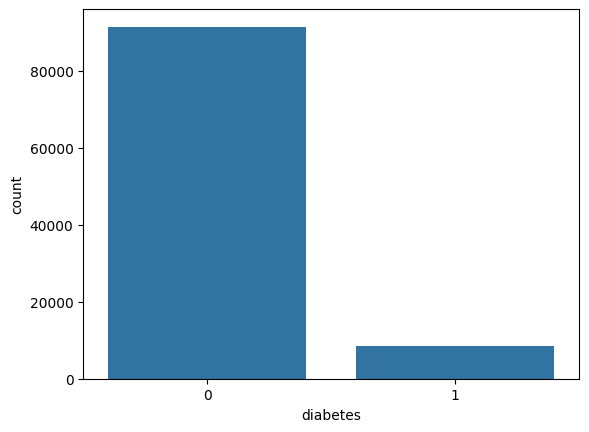

In [93]:
sns.countplot(x='diabetes', data=df)
#Seaborn Countplot

This chart shows the target variable distribution. Most records belong to the non-diabetic class, while diabetic cases are fewer. Therefore, the dataset is imbalanced.


<Axes: xlabel='gender', ylabel='count'>

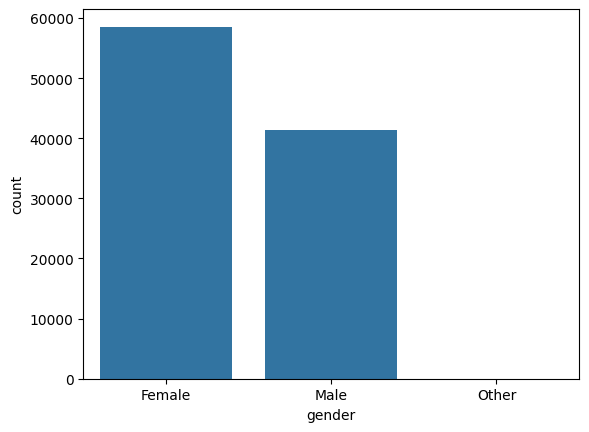

In [94]:
sns.countplot(x='gender', data=df)

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'never'),
  Text(1, 0, 'No Info'),
  Text(2, 0, 'current'),
  Text(3, 0, 'former'),
  Text(4, 0, 'ever'),
  Text(5, 0, 'not current')])

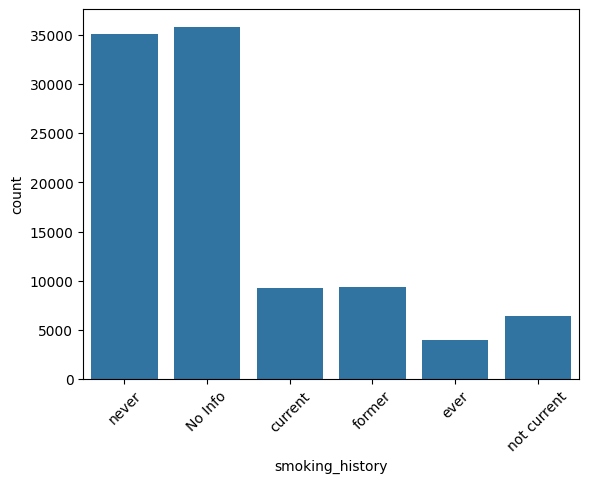

In [95]:
sns.countplot(x='smoking_history', data=df)
plt.xticks(rotation=45)

<Axes: xlabel='gender', ylabel='count'>

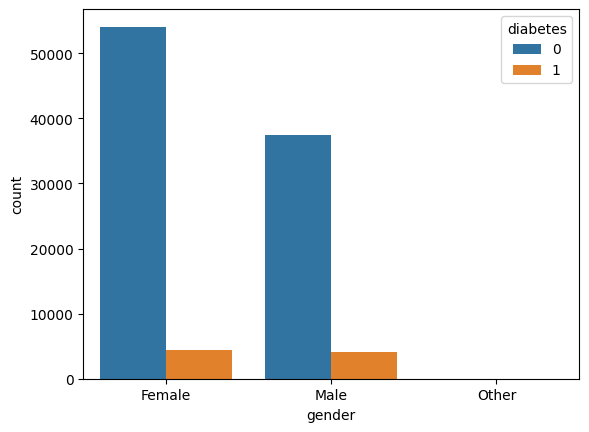

In [96]:
sns.countplot(x='gender', hue='diabetes', data=df)

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'never'),
  Text(1, 0, 'No Info'),
  Text(2, 0, 'current'),
  Text(3, 0, 'former'),
  Text(4, 0, 'ever'),
  Text(5, 0, 'not current')])

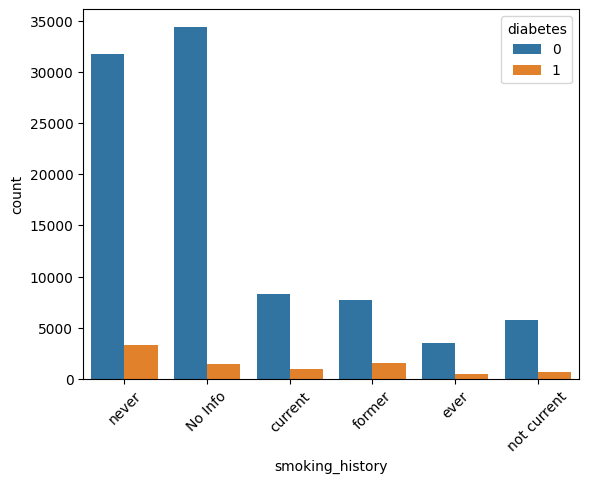

In [97]:
sns.countplot(x='smoking_history', hue='diabetes', data=df)
plt.xticks(rotation=45)

This heatmap shows the correlation between features. Blood glucose level and HbA1c level are the most correlated variables with diabetes, followed by age and BMI.


# Encoding 

In [98]:

# creat encoder
le_gender = LabelEncoder()
le_smoking = LabelEncoder()

# تحويل الأعمدة
df['gender'] = le_gender.fit_transform(df['gender'])
df['smoking_history'] = le_smoking.fit_transform(df['smoking_history'])

In [99]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,4,25.19,6.6,140,0
1,0,54.0,0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,4,27.32,5.7,158,0
3,0,36.0,0,0,1,23.45,5.0,155,0
4,1,76.0,1,1,1,20.14,4.8,155,0


Data cleaning was performed by checking missing values, duplicate records, categorical values consistency, and numerical ranges. The dataset was found to be clean and suitable for modeling.

<Axes: >

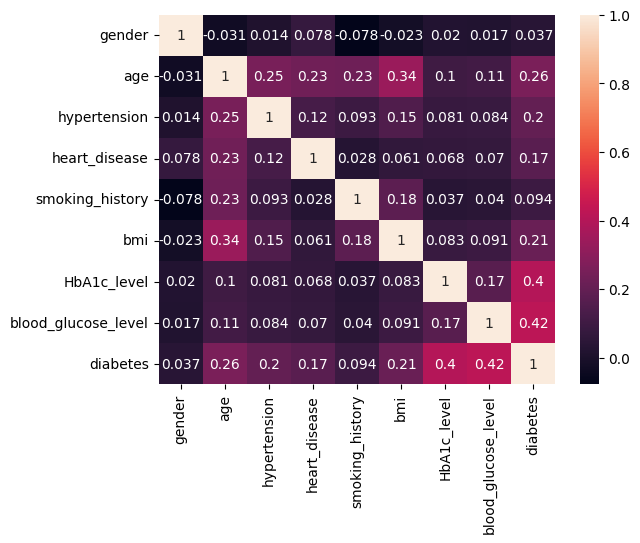

In [100]:
sns.heatmap(df.corr(), annot=True)

<Axes: xlabel='age', ylabel='Count'>

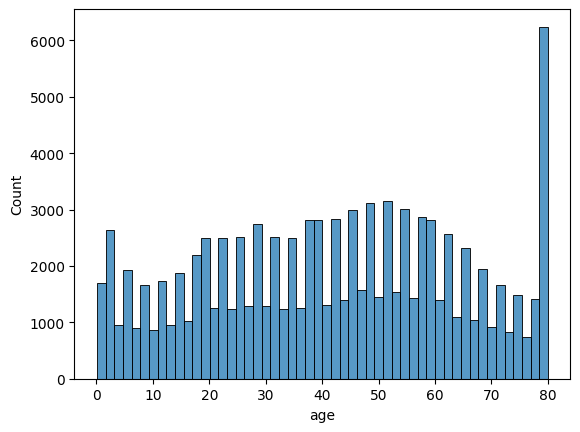

In [101]:
sns.histplot(df['age'])

<Axes: xlabel='bmi', ylabel='Count'>

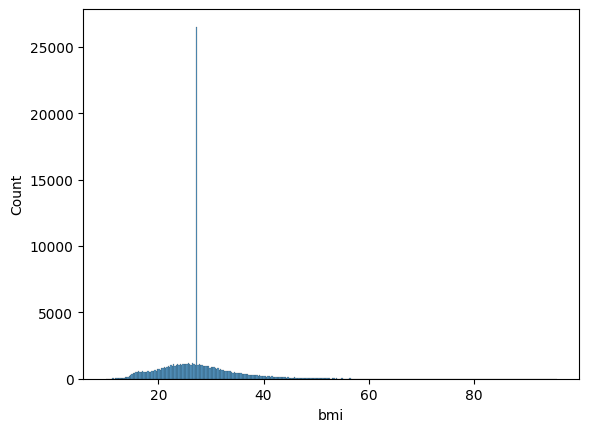

In [102]:
sns.histplot(df['bmi'])

<Axes: xlabel='diabetes', ylabel='blood_glucose_level'>

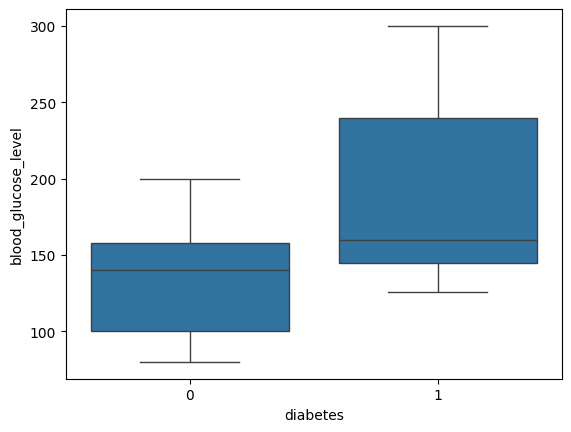

In [103]:
sns.boxplot(x='diabetes', y='blood_glucose_level', data=df)

<Axes: xlabel='diabetes', ylabel='HbA1c_level'>

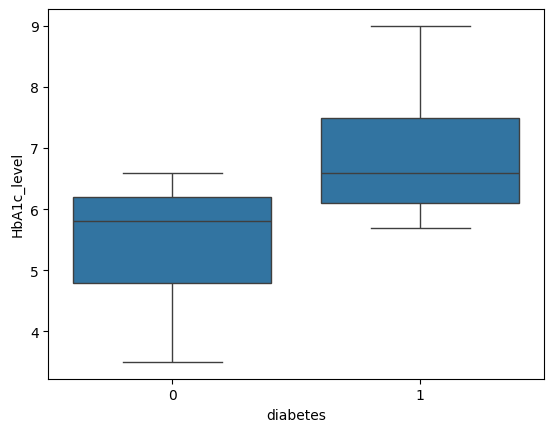

In [104]:
sns.boxplot(x='diabetes', y='HbA1c_level', data=df)

# Machine Learning Preparation

In [105]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']

Split data 


In [106]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [107]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [108]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [109]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(80000, 8)
(20000, 8)


In [110]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [111]:
y_pred = model.predict(X_test)

In [112]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.958


In [113]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18300
           1       0.84      0.62      0.72      1700

    accuracy                           0.96     20000
   macro avg       0.90      0.81      0.85     20000
weighted avg       0.96      0.96      0.96     20000



In [114]:
print(confusion_matrix(y_test, y_pred))

[[18100   200]
 [  640  1060]]


In [115]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18300
           1       0.84      0.62      0.72      1700

    accuracy                           0.96     20000
   macro avg       0.90      0.81      0.85     20000
weighted avg       0.96      0.96      0.96     20000



In [116]:
rf_model = RandomForestClassifier()

rf_model.fit(X_train_smote, y_train_smote)

RandomForestClassifier()

In [117]:
y_pred_rf = rf_model.predict(X_test)

In [118]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.95865


In [119]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     18300
           1       0.76      0.75      0.75      1700

    accuracy                           0.96     20000
   macro avg       0.87      0.86      0.87     20000
weighted avg       0.96      0.96      0.96     20000



In [120]:
print(confusion_matrix(y_test, y_pred_rf))

[[17901   399]
 [  428  1272]]


In [121]:
svm_model = SVC()
svm_model.fit(X_train_scaled, y_train)

SVC()

In [122]:
y_pred_svm = svm_model.predict(X_test_scaled)

In [123]:
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))


SVM Accuracy: 0.9645


In [124]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98     18300
           1       0.97      0.60      0.74      1700

    accuracy                           0.96     20000
   macro avg       0.97      0.80      0.86     20000
weighted avg       0.96      0.96      0.96     20000



In [125]:
print(confusion_matrix(y_test, y_pred_svm))

[[18271    29]
 [  681  1019]]


# Best Model Selection

Random Forest achieved the best overall performance compared with Logistic Regression and SVM.

In [126]:
#save model 
import joblib

joblib.dump(rf_model, "best_diabetes_model.pkl")

['best_diabetes_model.pkl']

The columns on which the model is based

In [127]:
importance = rf_model.feature_importances_
features = X.columns

import pandas as pd

imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(imp_df)

               Feature  Importance
6          HbA1c_level    0.416367
7  blood_glucose_level    0.253247
1                  age    0.179745
5                  bmi    0.107772
4      smoking_history    0.030068
0               gender    0.007645
2         hypertension    0.003131
3        heart_disease    0.002025


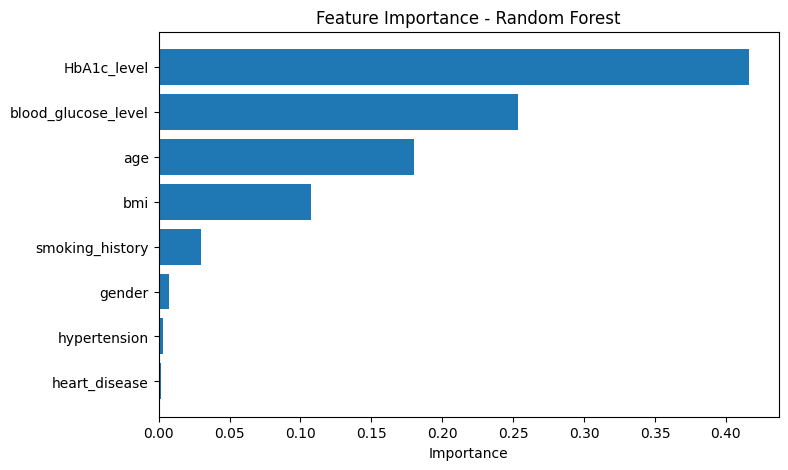

In [128]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(imp_df['Feature'], imp_df['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.show()

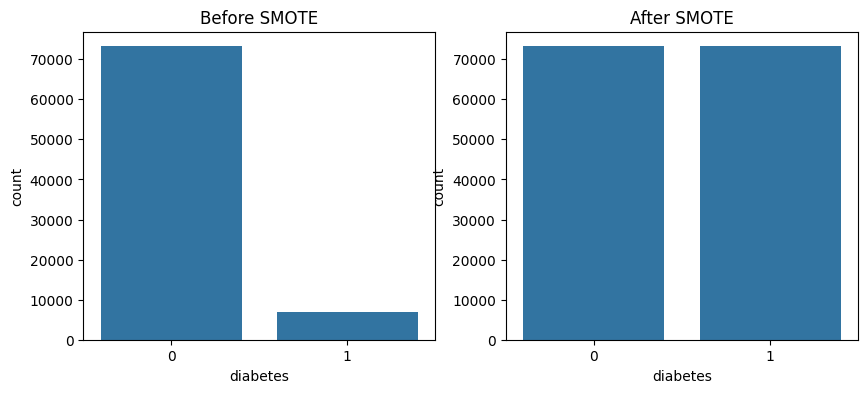

In [129]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.countplot(x=y_train)
plt.title("Before SMOTE")

plt.subplot(1,2,2)
sns.countplot(x=y_train_smote)
plt.title("After SMOTE")

plt.show()

# Final Conclusion

Random Forest was selected as the final model because it achieved the best overall performance among all tested models.